## Detect Hidden Charges + Keyword Frequency

### import libraries & load data

In [12]:
import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sample_car_contracts.csv")
df.head()


,id,customer_name,email_id,phone_no,contract_type,vehicle_type,monthly_emi,interest_rate,tenure_months,clause_summary,risk_flag,issue_type,recommended_action
0,1,Arjun Mehta,arjun.mehta@example.com,9876543210,New Car Loan,Sedan,13450,8.5,60,Includes prepayment penalty clause; mandatory ...,Low,NaN,No action needed; review terms annually
1,2,Pooja Reddy,pooja.reddy@example.com,9123456780,Used Car Loan,Hatchback,8900,10.2,48,Warranty disclaimer clause; repossession claus...,Medium,Short notice period,Renegotiate notice duration to 30 days
2,3,Rahul Sharma,rahul.sharma@example.com,9988776655,Electric Vehicle Loan,EV SUV,15200,7.8,72,Battery degradation liability unclear; high pr...,High,Ambiguous liability,Clarify battery warranty with dealership
3,4,Neha Kapoor,neha.kapoor@example.com,9090909090,Refinance Loan,Sedan,11200,9.1,36,Interest reset clause; floating rate adjustmen...,Low,NaN,Monitor rate resets
4,5,Vikram Singh,vikram.singh@example.com,9812345678,New Car Loan,Compact SUV,14500,8.2,60,Mandatory GPS installation; late fee escalation,Medium,Escalating charges,Limit late fee percentage


In [13]:
# Check dataframe info and missing values
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())
print("\nDataframe shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  20 non-null     int64  
 1   customer_name       20 non-null     object 
 2   email_id            20 non-null     object 
 3   phone_no            20 non-null     int64  
 4   contract_type       20 non-null     object 
 5   vehicle_type        20 non-null     object 
 6   monthly_emi         20 non-null     int64  
 7   interest_rate       20 non-null     float64
 8   tenure_months       20 non-null     int64  
 9   clause_summary      20 non-null     object 
 10  risk_flag           20 non-null     object 
 11  issue_type          13 non-null     object 
 12  recommended_action  20 non-null     object 
dtypes: float64(1), int64(4), object(8)
memory usage: 2.2+ KB
None

Missing values:
id                    0
customer_name         0
email_id              0
phone_

### Create hidden_charges_flag

In [14]:
keywords = ["fee", "penalty", "late", "extra", "charge", "charges"]

pattern = re.compile(r"\b(" + "|".join(keywords) + r")\b", re.IGNORECASE)

df["hidden_charges_flag"] = df["clause_summary"].apply(
    lambda text: 1 if pattern.search(text) else 0
)

df[["clause_summary", "hidden_charges_flag"]].head()


,clause_summary,hidden_charges_flag
0,Includes prepayment penalty clause; mandatory ...,1
1,Warranty disclaimer clause; repossession claus...,0
2,Battery degradation liability unclear; high pr...,1
3,Interest reset clause; floating rate adjustmen...,0
4,Mandatory GPS installation; late fee escalation,1


### Count hidden charges by risk group

In [15]:
hidden_count = df.groupby("risk_flag")["hidden_charges_flag"].sum()
hidden_count


risk_flag
High      2
Low       2
Medium    4
Name: hidden_charges_flag, dtype: int64

### Hidden charges count per risk_flag

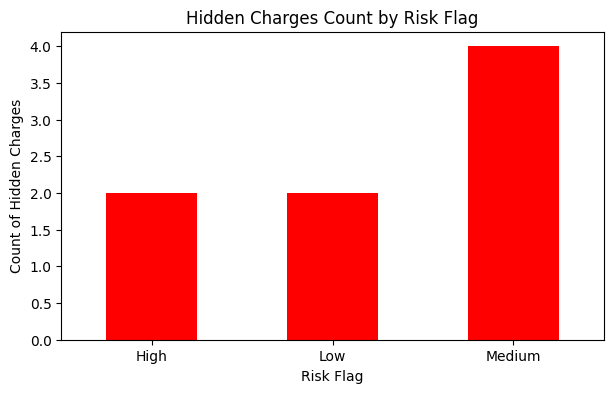

In [16]:
plt.figure(figsize=(7,4))
hidden_count.plot(kind="bar", color="red")
plt.title("Hidden Charges Count by Risk Flag")
plt.xlabel("Risk Flag")
plt.ylabel("Count of Hidden Charges")
plt.xticks(rotation=0)
plt.show()


### Extract keywords from HIGH-risk customers

In [17]:
from collections import Counter

high_text = " ".join(df[df["risk_flag"]=="High"]["clause_summary"].astype(str)).lower()

words = re.findall(r"[a-z]{3,}", high_text)

freq = Counter(words)
top_words = freq.most_common(10)

top_words


[('clause', 5),
 ('liability', 2),
 ('unclear', 2),
 ('vehicle', 2),
 ('repossession', 2),
 ('without', 2),
 ('mandatory', 2),
 ('battery', 1),
 ('degradation', 1),
 ('high', 1)]

### Convert keyword list to DataFrame for groupby-style display

In [18]:
df_keywords = pd.DataFrame(top_words, columns=["keyword", "frequency"])
df_keywords


,keyword,frequency
0,clause,5
1,liability,2
2,unclear,2
3,vehicle,2
4,repossession,2
5,without,2
6,mandatory,2
7,battery,1
8,degradation,1
9,high,1


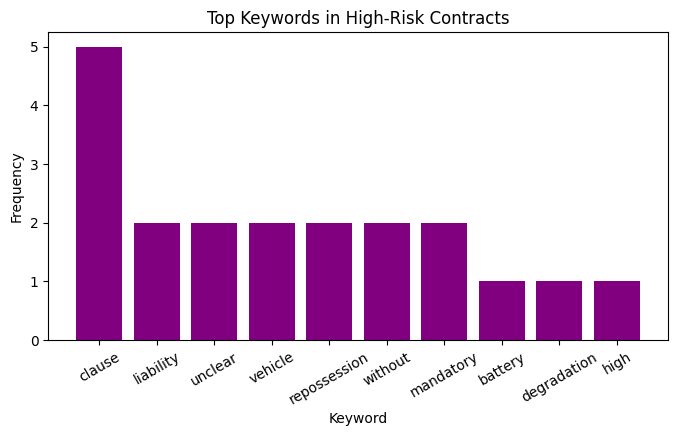

In [19]:
plt.figure(figsize=(8,4))
plt.bar(df_keywords["keyword"], df_keywords["frequency"], color="purple")
plt.title("Top Keywords in High-Risk Contracts")
plt.xlabel("Keyword")
plt.ylabel("Frequency")
plt.xticks(rotation=30)
plt.show()


A bar chart of the keyword frequencies further highlighted the prominence of these terms in High-risk loan documents. The insights clearly showed that hidden charges and unclear penalty structures are more concentrated in High-risk contracts, making them critical areas for review and customer guidance.